# Object Detection Tasks
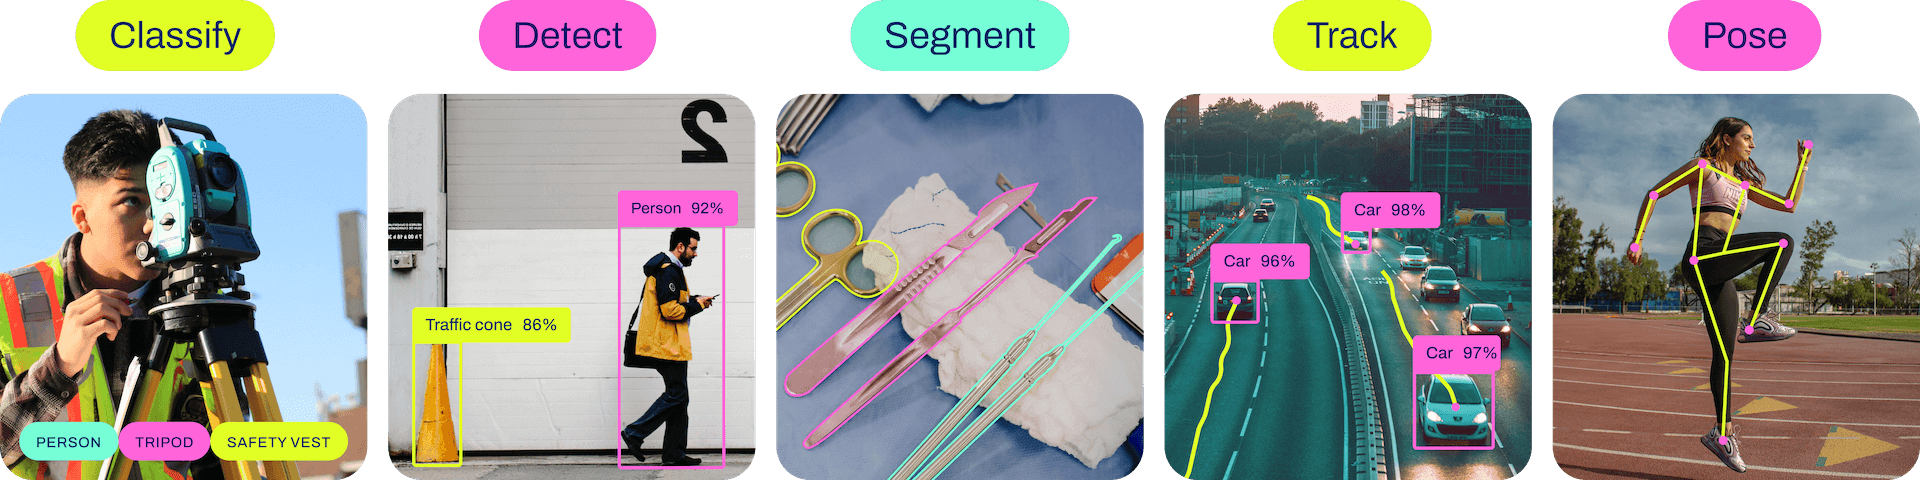

# Haar Cascades

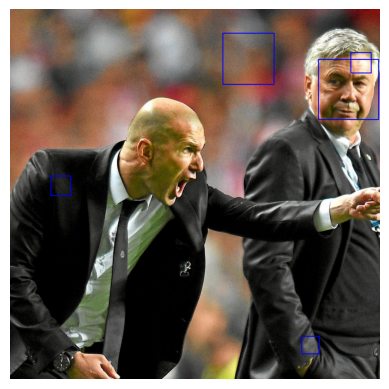

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
img = cv2.imread("../data/img.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.2, 1)


for (x,y,w,h) in faces:
    img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Playing with Yolo v8

### 0. Setup

In [2]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.60  Python-3.10.19 torch-2.4.1+cpu CPU (Intel Core(TM) i5-8265U 1.60GHz)
Setup complete  (8 CPUs, 11.9 GB RAM, 576.0/599.8 GB disk)


### 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).


In [3]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.3.60 🚀 Python-3.10.19 torch-2.4.1+cpu CPU (Intel Core(TM) i5-8265U 1.60GHz)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 c:\Programming\AI\ai-portfolio\assignments\real_time_object_detector_day12\notebook\zidane.jpg: 384x640 2 persons, 1 tie, 146.5ms
Speed: 2.1ms preprocess, 146.5ms inference, 17.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs\detect\predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


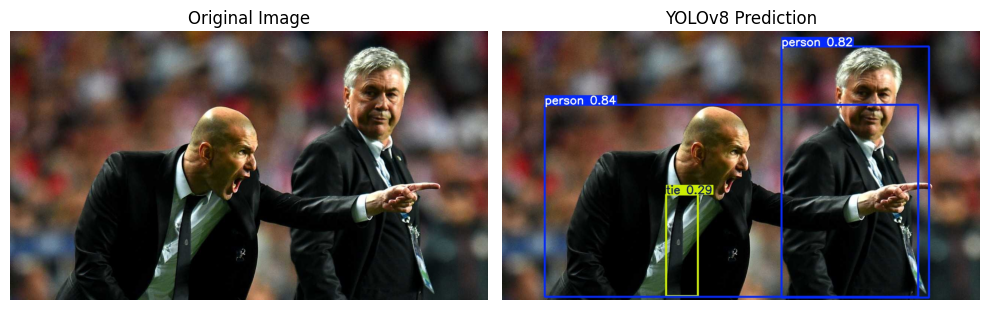

In [4]:
import matplotlib.pyplot as plt

img1 = cv2.imread("../data/zidane.jpg")
img2 = cv2.imread("runs/detect/predict/zidane.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the images in the subplots
axes[0].imshow(img1_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off') # Hide axes

axes[1].imshow(img2_rgb)
axes[1].set_title("YOLOv8 Prediction")
axes[1].axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

In [5]:
# from ultralytics import YOLO
# import cv2
# import numpy as np

# # Load the YOLOv8 model
# model = YOLO('yolov8n.pt')

# # Open the default camera
# cap = cv2.VideoCapture(0)

# # Check if camera opened successfully
# if not cap.isOpened():
#     print("Error: Could not open camera.")
# else:
#     while True:
#         # Read a frame from the camera
#         ret, frame = cap.read()

#         # If frame is read correctly ret is True
#         if not ret:
#             print("Error: Can't receive frame (stream end?). Exiting ...")
#             break

#         # Perform object detection on the frame
#         results = model(frame, verbose=False) # Set verbose=False to reduce output

#         # Annotate the frame with detection results
#         annotated_frame = results[0].plot()

#         # Display the annotated frame
#         plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
#         plt.axis("off")
#         plt.show()

#         # Break the loop if 'q' is pressed
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break

#     # Release the capture and destroy all windows
#     cap.release()
#     cv2.destroyAllWindows()